In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

In [ ]:
# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [ ]:
print(df.info())         # Data types and memory usage
print(df.describe())
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   

,0
student_id,0
major,0
year,0
exam_score,10
assignments_completed,0
hours_studied,5


In [ ]:
df['exam_score'].fillna(df['exam_score'].mean(), inplace=True)
df['hours_studied'].fillna(df['hours_studied'].median(), inplace=True)

avg_scores = df.groupby('major')['exam_score'].mean()
print(avg_scores)

df_sorted = df.sort_values('exam_score', ascending=False)

df['performance'] = np.where(df['exam_score'] > 90, 'Excellent', np.where(df['exam_score'] >= 80, 'Good', np.where(df['exam_score'] >= 70, 'Average', 'Needs Improvement')))

summary = df.groupby(['major', 'year']).agg({'student_id': 'count', 'exam_score': 'mean','hours_studied': 'mean'})
print(summary)

# Sorting
df_sorted = df.sort_values('exam_score', ascending=False)
top_5 = df.nlargest(5, 'exam_score')
print(top_5)

pivot = df.pivot_table(values = 'exam_score', index = 'major', columns = 'year', aggfunc = 'mean')
print(pivot)

major
Biology    75.503428
CS         76.405302
Math       74.737620
Physics    75.414222
Name: exam_score, dtype: float64
              student_id  exam_score  hours_studied
major   year                                       
Biology 1             13   76.570059      12.677806
        2             12   74.900237      13.426372
        3             14   80.179011      14.525693
        4             15   70.697689      14.253944
CS      1             12   77.021982      13.039480
        2              7   76.155936      13.955238
        3              9   72.347626      15.039892
        4             18   78.119997      16.275541
Math    1             11   74.203521      19.001215
        2              9   81.318598      12.313932
        3             10   72.017537      15.175871
        4             16   73.103066      17.365852
Physics 1             13   77.836696      13.489911
        2             12   73.277734      14.616778
        3             17   73.140444      14.

/tmp/ipykernel_16381/3930056834.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['exam_score'].fillna(df['exam_score'].mean(), inplace=True)
/tmp/ipykernel_16381/3930056834.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

Exercis 6

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

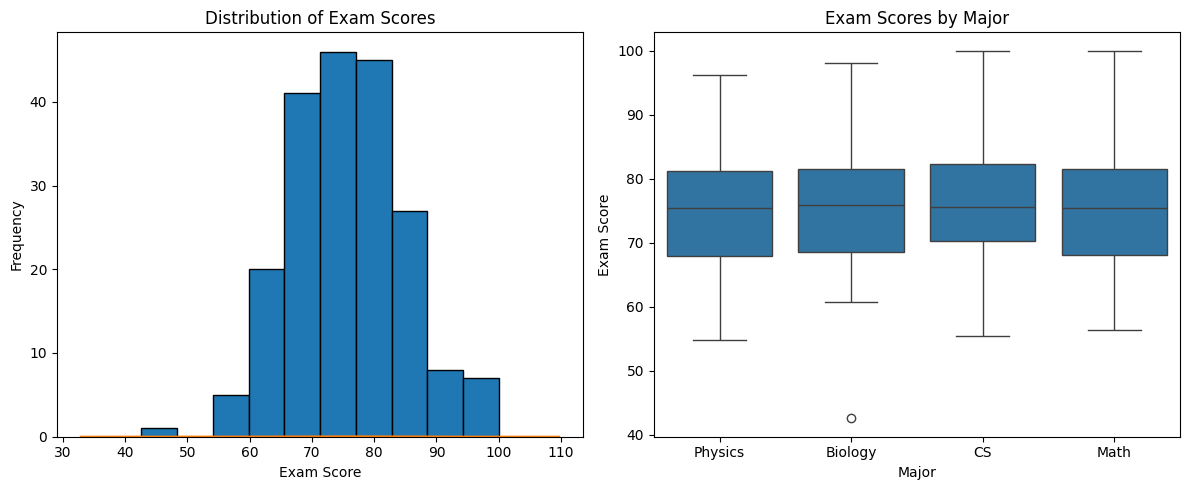

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12, 5))
# Histogram with KDE
ax[0].hist(df['exam_score'], bins=10, edgecolor='black')
sns.kdeplot(df['exam_score'], ax=ax[0])

ax[0].set_title('Distribution of Exam Scores')
ax[0].set_xlabel('Exam Score')
ax[0].set_ylabel('Frequency')

# Box plot by major
sns.boxplot(x='major', y='exam_score', data=df, ax=ax[1])

ax[1].set_title('Exam Scores by Major')
ax[1].set_xlabel('Major')
ax[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

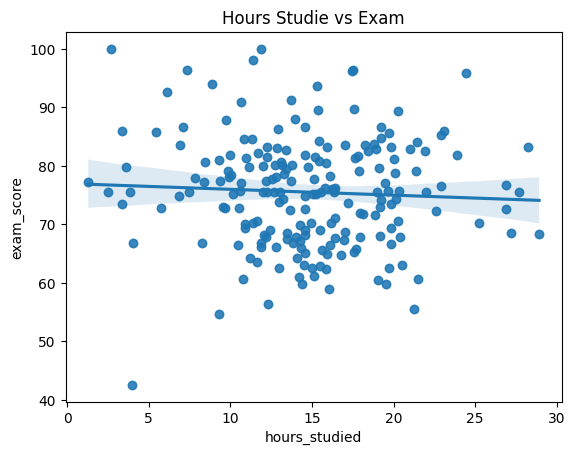

In [ ]:
# Scatter plot
plt.scatter(df['hours_studied'], df['exam_score'], alpha=0.4)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studie vs Exam')
sns.regplot(x='hours_studied', y='exam_score', data=df)
plt.show()

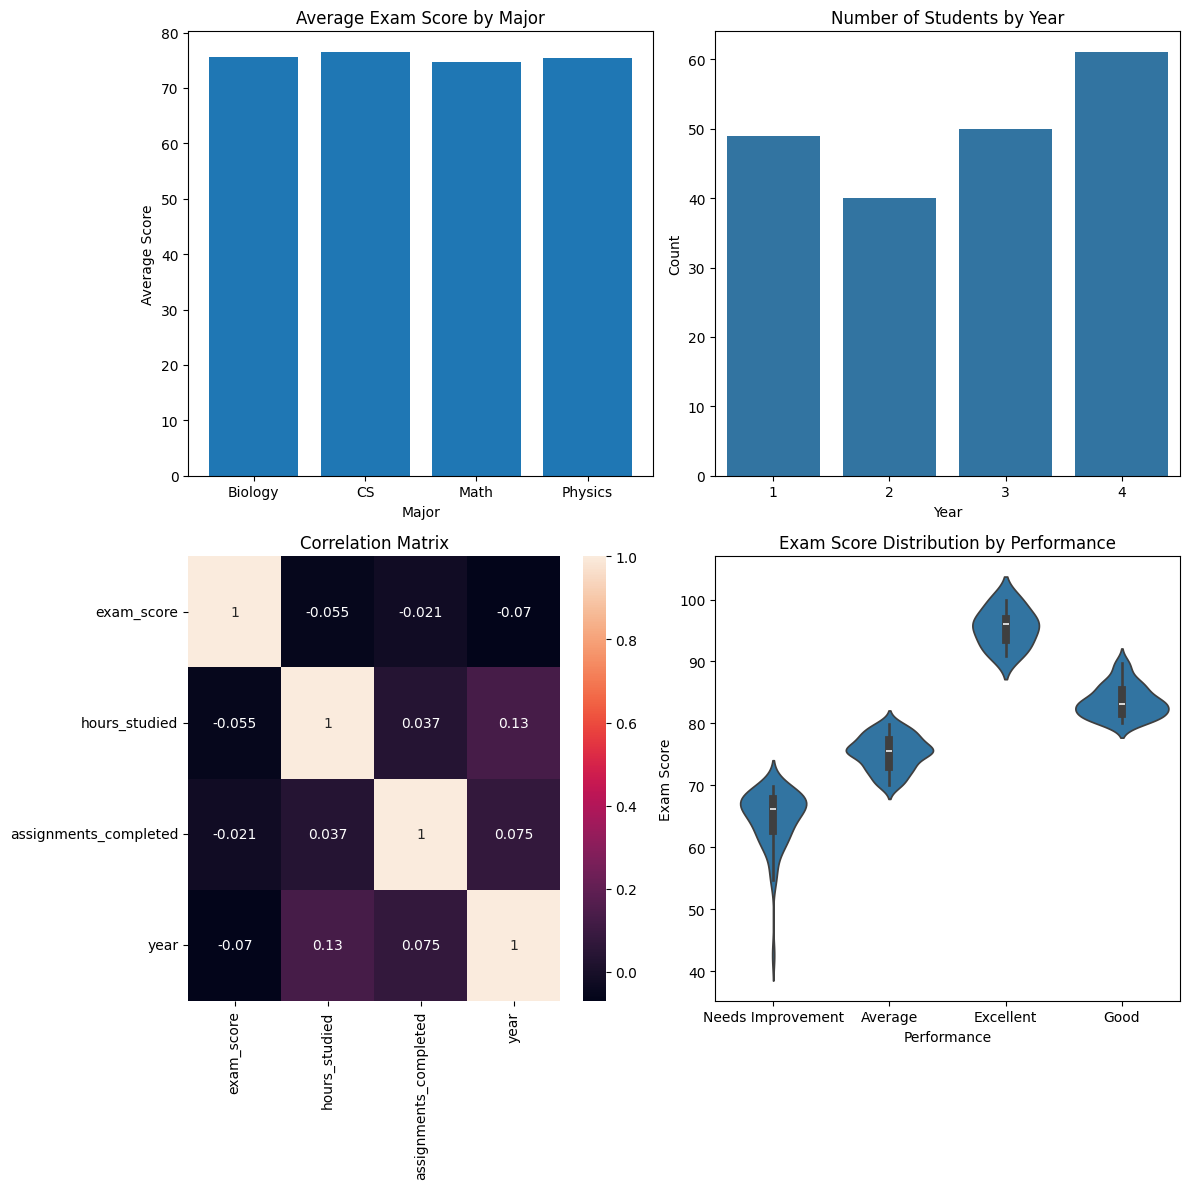

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(12,12))
#Bar chart
avg_scores = df.groupby('major')['exam_score'].mean()

ax[0,0].bar(avg_scores.index, avg_scores.values)
ax[0,0].set_title('Average Exam Score by Major')
ax[0,0].set_xlabel('Major')
ax[0,0].set_ylabel('Average Score')

#Count plot
sns.countplot(data=df, x='year', ax=ax[0,1])

ax[0,1].set_title('Number of Students by Year')
ax[0,1].set_xlabel('Year')
ax[0,1].set_ylabel('Count')

# Heat map
corr = df[['exam_score',
           'hours_studied',
           'assignments_completed',
           'year']].corr()

sns.heatmap(corr, annot=True, ax=ax[1,0])

ax[1,0].set_title('Correlation Matrix')

#Violin plot
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=ax[1,1]
)

ax[1,1].set_title('Exam Score Distribution by Performance')
ax[1,1].set_xlabel('Performance')
ax[1,1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()


Exercise 7

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

#Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

#Create DataFrame
customers = pd.DataFrame({'age': ages, 'income': income, 'purchase_frequency': purchase_freq, 'avg_purchase_value': avg_purchase_value
})

max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = (1 - customers['purchase_frequency'] / max_frequency)
customers['CLV'] = (customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk']))

#Create age groups
customers['age_group'] = pd.cut(customers['age'], bins=[18, 25, 35, 50, 70], labels=['18-25', '26-35', '36-50', '51-70'], include_lowest=True)
print(customers[['age', 'age_group']].head())

#Grouping by categories
summary = customers.groupby('age_group').agg(number_of_customers=('age', 'count'), average_income=('income', 'mean'), average_CLV=('CLV', 'mean'), total_CLV=('CLV', 'sum'))
print(summary)

#idenitfy top 10% by clv
top_10_percent = customers.nlargest(int(0.1 * len(customers)), 'CLV')
print(top_10_percent)


   age age_group
0   56     51-70
1   69     51-70
2   46     36-50
3   32     26-35
4   60     51-70
           number_of_customers  average_income  average_CLV      total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683


/tmp/ipykernel_16381/1827782005.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = customers.groupby('age_group').agg(number_of_customers=('age', 'count'), average_income=('income', 'mean'), average_CLV=('CLV', 'mean'), total_CLV=('CLV', 'sum'))


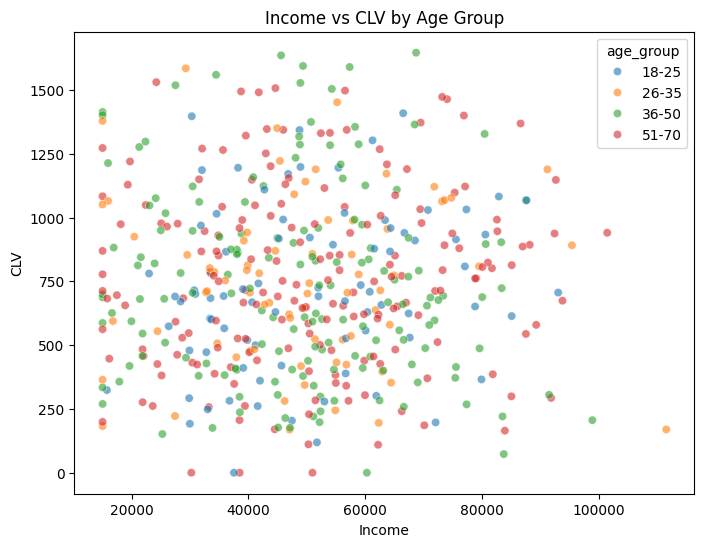

In [26]:
#Visualisations
#scatterplot
plt.figure(figsize=(8,6))

sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group', alpha=0.6)

plt.title('Income vs CLV by Age Group')
plt.xlabel('Income')
plt.ylabel('CLV')

plt.show()

/tmp/ipykernel_16381/2029218578.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby('age_group')['CLV'].mean()


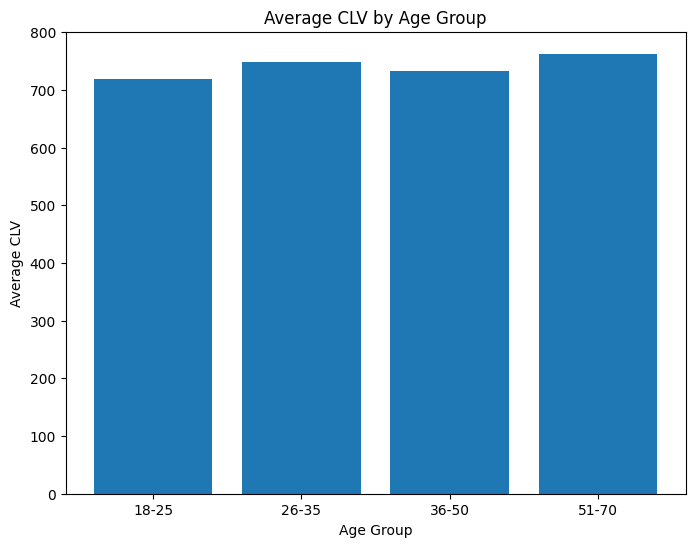

In [27]:
#Barchart
avg_clv = customers.groupby('age_group')['CLV'].mean()

plt.figure(figsize=(8,6))

plt.bar(
    avg_clv.index,
    avg_clv.values
)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')

plt.show()

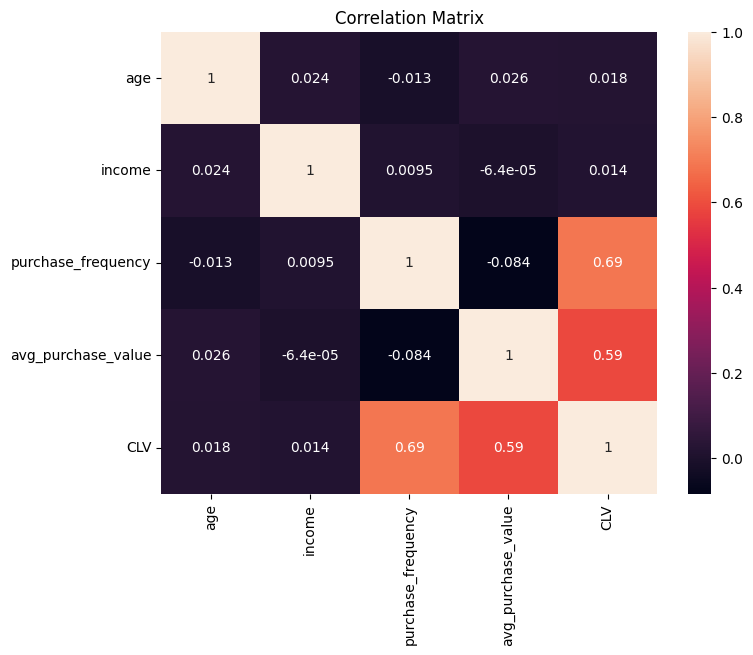

In [28]:
#Correlation heatmap
corr = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

Customer Lifetime Value(CLV) is influenced to a great degree by purchase frequency and average purchase value. Customers who purchase a lot tend to have a higher clv. This implies a positive relation between clv and purchase frequency and average purchase value, while age and income have lower effects. Using thi information, the company should focus on incentives to make customers purchase more such as loyalty schemes.